# Chain of Extraction

This is a quick implementation of the Chain of Extraction + Fast & Slow thinking idea for text-to-JSON task.

## Imports

In [8]:
import json
from typing import Annotated, Any

from litellm import completion
from loguru import logger
from openai import OpenAI
from pydantic import BaseModel, Field

import agent_k.config.prompts as config_prompts
from agent_k.setup.load_43_101 import list_43_101_reports

# Configs
client = OpenAI()
TEMPERATURE = 0.5
MODEL = "gpt-4o-mini"
TOP_P = 0.95

## Schemas

In [9]:
class MineralSiteMetadata(BaseModel):
    mineral_site_name: str = Field(
        ..., description="The name of the mineral site that the report is about"
    )
    state_or_province: str = Field(
        ..., description="The state or province where the mineral site is located"
    )
    country: str = Field(
        ..., description="The country where the mineral site is located"
    )
    total_grade: float = Field(
        "Not Found",
        description="The total grade of all the nickel deposits in decimal format",
    )
    total_tonnage: float = Field(
        "Not Found",
        description="The total tonnage of all the nickel deposits in million tonnes.",
    )
    top_1_deposit_type: str = Field(
        "Not Found", description="The most likely deposit type of the mineral site"
    )
    top_1_deposit_environment: str = Field(
        "Not Found",
        description="The most likely deposit environment of the mineral site",
    )


schema = MineralSiteMetadata.model_json_schema()
schema_str = json.dumps(schema)
print(schema)
print(schema_str)

{'properties': {'mineral_site_name': {'description': 'The name of the mineral site that the report is about', 'title': 'Mineral Site Name', 'type': 'string'}, 'state_or_province': {'description': 'The state or province where the mineral site is located', 'title': 'State Or Province', 'type': 'string'}, 'country': {'description': 'The country where the mineral site is located', 'title': 'Country', 'type': 'string'}, 'total_grade': {'default': 'Not Found', 'description': 'The total grade of all the nickel deposits in decimal format', 'title': 'Total Grade', 'type': 'number'}, 'total_tonnage': {'default': 'Not Found', 'description': 'The total tonnage of all the nickel deposits in million tonnes.', 'title': 'Total Tonnage', 'type': 'number'}, 'top_1_deposit_type': {'default': 'Not Found', 'description': 'The most likely deposit type of the mineral site', 'title': 'Top 1 Deposit Type', 'type': 'string'}, 'top_1_deposit_environment': {'default': 'Not Found', 'description': 'The most likely 

In [10]:
class Example1(BaseModel):
    name: str
    address: str
    total_attendees: int
    oldest_attendee: str


class Example2(BaseModel):
    product_name: str
    product_type: str
    price: float
    discount: float


class Example3(BaseModel):
    address: str
    province: str
    country: str
    total_sales: float


schema_example1 = json.dumps(Example1.model_json_schema())
schema_example2 = json.dumps(Example2.model_json_schema())
schema_example3 = json.dumps(Example3.model_json_schema())
# replace "{" with "{{" and "}" with "}}"
schema_example1 = schema_example1.replace("{", "{{").replace("}", "}}")
schema_example2 = schema_example2.replace("{", "{{").replace("}", "}}")
schema_example3 = schema_example3.replace("{", "{{").replace("}", "}}")
print(schema_example1)
print(schema_example2)
print(schema_example3)

{{"properties": {{"name": {{"title": "Name", "type": "string"}}, "address": {{"title": "Address", "type": "string"}}, "total_attendees": {{"title": "Total Attendees", "type": "integer"}}, "oldest_attendee": {{"title": "Oldest Attendee", "type": "string"}}}}, "required": ["name", "address", "total_attendees", "oldest_attendee"], "title": "Example1", "type": "object"}}
{{"properties": {{"product_name": {{"title": "Product Name", "type": "string"}}, "product_type": {{"title": "Product Type", "type": "string"}}, "price": {{"title": "Price", "type": "number"}}, "discount": {{"title": "Discount", "type": "number"}}}}, "required": ["product_name", "product_type", "price", "discount"], "title": "Example2", "type": "object"}}
{{"properties": {{"address": {{"title": "Address", "type": "string"}}, "province": {{"title": "Province", "type": "string"}}, "country": {{"title": "Country", "type": "string"}}, "total_sales": {{"title": "Total Sales", "type": "number"}}}}, "required": ["address", "provin

## Prompts

In [11]:
SCHEMA_DECOMPOSE_SYS_PROMPT = """You are a helpful agent that groups entities in a JSON schema into two categories:
1. Simple entities in the JSON schema that can be extracted directly from the text.
2. Complex entities in the JSON schema that require reasoning or additional information to be extracted. Complex entities may include composite entities that need further decomposition or non-composite entities that require extra context for extraction.

You should enclose your reasoning within <thinking> XML tags and output the result within <output> XML tags."""

DECOMPOSE_USER_PROMPT_TEMPLATE = """
# Example 1
Given the following JSON schema:
```
{{"properties": {{"name": {{"title": "Name", "type": "string"}}, "address": {{"title": "Address", "type": "string"}}, "total_attendees": {{"title": "Total Attendees", "type": "integer"}}, "oldest_attendee": {{"title": "Oldest Attendee", "type": "string"}}}}, "required": ["name", "address", "total_attendees", "oldest_attendee"], "title": "Example", "type": "object"}}
```
Output:
<thinking>
"name" and "address" are not complex entities and can be extracted directly from the text. "total_attendees" is likely a complex entity because it requires extracting individual attendees and counting them. Oldest attendee is a complex entity because it requires extracting the oldest attendee from the list of attendees.
</thinking>
<output>
1. Simple entities: ["name", "address"]
2. Complex entities: ["total_attendees", "oldest_attendee"]
</output>

# Example 2
Given the following JSOn schema:
```
{{"properties": {{"product_name": {{"title": "Product Name", "type": "string"}}, "product_type": {{"title": "Product Type", "type": "string"}}, "price": {{"title": "Price", "type": "number"}}, "discount": {{"title": "Discount", "type": "number"}}}}, "required": ["product_name", "product_type", "price", "discount"], "title": "Example2", "type": "object"}}
```
Output:
<thinking>
"product_name", "product_type", "price", and "discount" are all not complex entities and can be extracted directly from the text.
</thinking>
<output>
1. Simple entities: ["product_name", "product_type", "price", "discount"]
2. Complex entities: []
</output>

# Example 3
Given the following JSON schema:
```
{{"properties": {{"address": {{"title": "Address", "type": "string"}}, "province": {{"title": "Province", "type": "string"}}, "country": {{"title": "Country", "type": "string"}}, "total_sales": {{"title": "Total Sales", "type": "number"}}}}, "required": ["address", "province", "country", "total_sales"], "title": "Example3", "type": "object"}}
```
Output:
<thinking>
"address", "province", and "country" are not complex entities and can be extracted directly from the text. "total_sales" is a complex entity because it requires extracting separate sales from the text and then summing them up.
</thinking>
<output>
1. Simple entities: ["address", "province", "country"]
2. Complex entities: ["total_sales"]
</output>

# Example 4
Given the following JSON schema:
```
{json_schema}
```
Output:
"""

## Helper Functions

In [12]:
def split_json_schema(schema: dict, field_lists: list[list[str]]) -> list[dict]:
    """
    Splits a JSON schema into multiple schemas based on provided field lists.

    Args:
        schema (dict): The input JSON schema.
        field_lists (list of list of str): Each inner list contains fields for a separate schema.

    Returns:
        list of dict: A list of JSON schemas corresponding to each field list.
    """
    # Extract properties and required fields from the original schema
    original_properties = schema.get("properties", {})
    original_required = set(schema.get("required", []))

    schemas = []
    for field_list in field_lists:
        new_schema = {"type": "object", "properties": {}, "required": []}
        # Extract properties and required fields based on the field list
        for field in field_list:
            if field in original_properties:
                new_schema["properties"][field] = original_properties[field]
            if field in original_required:
                new_schema["required"].append(field)

        # Remove 'required' if empty
        if not new_schema["required"]:
            new_schema.pop("required")

        schemas.append(new_schema)

    return schemas


field_lists = [
    ["mineral_site_name", "state_or_province", "country"],
    ["total_grade", "total_tonnage"],
    ["top_1_deposit_type", "top_1_deposit_environment"],
]
result = split_json_schema(schema, field_lists)
for i, res in enumerate(result):
    print(f"Schema {i+1}:", res)

Schema 1: {'type': 'object', 'properties': {'mineral_site_name': {'description': 'The name of the mineral site that the report is about', 'title': 'Mineral Site Name', 'type': 'string'}, 'state_or_province': {'description': 'The state or province where the mineral site is located', 'title': 'State Or Province', 'type': 'string'}, 'country': {'description': 'The country where the mineral site is located', 'title': 'Country', 'type': 'string'}}, 'required': ['mineral_site_name', 'state_or_province', 'country']}
Schema 2: {'type': 'object', 'properties': {'total_grade': {'default': 'Not Found', 'description': 'The total grade of all the nickel deposits in decimal format', 'title': 'Total Grade', 'type': 'number'}, 'total_tonnage': {'default': 'Not Found', 'description': 'The total tonnage of all the nickel deposits in million tonnes.', 'title': 'Total Tonnage', 'type': 'number'}}}
Schema 3: {'type': 'object', 'properties': {'top_1_deposit_type': {'default': 'Not Found', 'description': 'Th

### Extract from PDF

In [13]:
def parse_json_code_block(assistant_response: str) -> dict[str, Any]:
    """Parse the JSON code block from the assistant response."""
    try:
        json_code_block = assistant_response.split("```json")[1].split("```")[0]
        return json.loads(json_code_block)
    except Exception as e:
        logger.error(f"Failed to parse JSON code block: {e}")
        return {}


def extract_from_pdf(
    pdf_path: str,
    json_schema: dict,
) -> str:
    """
    Extract entities from a PDF file using OpenAI Assistant.
    """

    relevant_entities_json_schema = json.dumps(json_schema)
    logger.debug(f"Relevant entities JSON schema: {relevant_entities_json_schema}")

    logger.info("Retrieving OpenAI assistant")
    assistant = client.beta.assistants.retrieve("asst_dbMIxMYwSocPIKpZ3KLnadWB")
    logger.debug(assistant)

    filename_to_id_map = list_43_101_reports()
    filename = pdf_path.split("/")[-1]
    file_id = filename_to_id_map[filename]

    logger.info("Creating thread with user message and file")
    thread = client.beta.threads.create(
        messages=[
            {
                "role": "user",
                "content": config_prompts.PDF_AGENT_USER_PROMPT.format(
                    relevant_entities_json_schema=relevant_entities_json_schema,
                ),
                "attachments": [
                    {
                        "file_id": file_id,
                        "tools": [
                            {"type": "file_search"},
                            {"type": "code_interpreter"},
                        ],
                    }
                ],
            },
        ],
    )

    logger.info("Starting assistant run")

    # Use the create and poll SDK helper to create a run and poll the status of
    # the run until it's in a terminal state.
    run = client.beta.threads.runs.create_and_poll(
        thread_id=thread.id,
        assistant_id=assistant.id,
    )
    messages = list(
        client.beta.threads.messages.list(thread_id=thread.id, run_id=run.id)
    )
    message_content = messages[0].content[0].text
    print(message_content)

    annotations = message_content.annotations
    citations = []
    for index, annotation in enumerate(annotations):
        message_content.value = message_content.value.replace(
            annotation.text, f"[{index}]"
        )
        if file_citation := getattr(annotation, "file_citation", None):
            cited_file = client.files.retrieve(file_citation.file_id)
            citations.append(f"[{index}] {cited_file.filename}")

    print(message_content.value)
    print("\n".join(citations))

    return message_content.value


def deep_extract(pdf_path: str, field, default, description, dtype):
    """
    Extract entities from a PDF file using OpenAI Assistant.
    """
    logger.info(f"Extracting {field} from {pdf_path}")
    assistant = client.beta.assistants.retrieve("asst_dbMIxMYwSocPIKpZ3KLnadWB")
    filename_to_id_map = list_43_101_reports()
    filename = pdf_path.split("/")[-1]
    file_id = filename_to_id_map[filename]

    logger.info("Creating thread with user message and file")
    thread = client.beta.threads.create(
        messages=[
            {
                "role": "user",
                "content": f"What's the {field} of the mineral site? {field} description: {description}. {field} data type: {dtype}. {field} default value: {default}\n",
                "attachments": [
                    {
                        "file_id": file_id,
                        "tools": [
                            {"type": "file_search"},
                            {"type": "code_interpreter"},
                        ],
                    }
                ],
            },
        ],
    )

    logger.info("Starting assistant run")

    # Use the create and poll SDK helper to create a run and poll the status of
    # the run until it's in a terminal state.
    run = client.beta.threads.runs.create_and_poll(
        thread_id=thread.id,
        assistant_id=assistant.id,
    )
    messages = list(
        client.beta.threads.messages.list(thread_id=thread.id, run_id=run.id)
    )
    message_content = messages[0].content[0].text
    print(message_content)

    annotations = message_content.annotations
    citations = []
    for index, annotation in enumerate(annotations):
        message_content.value = message_content.value.replace(
            annotation.text, f"[{index}]"
        )
        if file_citation := getattr(annotation, "file_citation", None):
            cited_file = client.files.retrieve(file_citation.file_id)
            citations.append(f"[{index}] {cited_file.filename}")

# LangGraphs

In [ ]:
from ast import literal_eval

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

llm = init_chat_model(MODEL, model_provider="openai")


def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    pdf_path: str  # 43-101 report record ID
    json_schema: dict  # Predefined JSON schema (Assumed it's available)

    # Populated by LLMs
    simple_entities: list[str]
    complex_entities: list[str]
    fast_extraction_agent_result: dict
    slow_extraction_agent_result: dict
    messages: Annotated[list, add_messages]
    final_extraction_result: dict


def schema_decompose(state: State):
    response = completion(
        model=MODEL,
        messages=[
            {"role": "system", "content": SCHEMA_DECOMPOSE_SYS_PROMPT},
            {
                "role": "user",
                "content": DECOMPOSE_USER_PROMPT_TEMPLATE.format(
                    json_schema=json.dumps(state["json_schema"])
                ),
            },
        ],
        temperature=TEMPERATURE,
        top_p=TOP_P,
    )

    # Parse the <output> XML tags
    output = response.choices[0].message.content
    simple_entities = []
    complex_entities = []
    for line in output.split("\n"):
        if line.startswith("1. Simple entities:"):
            simple_entities = line.split(":")[1].strip()
            simple_entities = literal_eval(simple_entities)
        elif line.startswith("2. Complex entities:"):
            complex_entities = line.split(":")[1].strip()
            complex_entities = literal_eval(complex_entities)

    logger.debug(f"Response: {response.choices[0].message.content}")
    logger.debug(f"Simple entities: {simple_entities}")
    logger.debug(f"Complex entities: {complex_entities}")

    return {
        "simple_entities": simple_entities,
        "complex_entities": complex_entities,
        "messages": [
            {"role": "assistant", "content": response.choices[0].message.content}
        ],
    }


def fast_and_slow_route(state: State):
    next_nodes = []
    if state["simple_entities"]:
        next_nodes.append("fast_extraction_agent")
    if state["complex_entities"]:
        next_nodes.append("slow_extraction_agent")
    if not next_nodes:
        next_nodes.append(END)
    return next_nodes


def fast_extraction_agent(state: State):
    fast_schema = split_json_schema(state["json_schema"], [state["simple_entities"]])[0]
    logger.debug(f"Fast schema: {fast_schema}")
    extraction_results = extract_from_pdf(state["pdf_path"], fast_schema)
    extraction_results_json = parse_json_code_block(extraction_results)

    return {"fast_extraction_agent_result": extraction_results_json}


def slow_extraction_agent(state: State):
    slow_schema = split_json_schema(state["json_schema"], [state["complex_entities"]])[
        0
    ]
    logger.debug(f"Slow schema: {slow_schema}")
    extraction_results = extract_from_pdf(state["pdf_path"], slow_schema)
    extraction_results_json = parse_json_code_block(extraction_results)

    return {"slow_extraction_agent_result": extraction_results_json}


def slow_extraction_agent_dpe(state: State):
    slow_schema = split_json_schema(state["json_schema"], [state["complex_entities"]])[
        0
    ]
    logger.debug(f"Slow schema: {slow_schema}")
    extraction_results = {}
    for entity_name, entity_schema in slow_schema["properties"].items():
        default = entity_schema.get("default", None)
        description = entity_schema.get("description", None)
        dtype = entity_schema.get("type", None)
        extraction_result = deep_extract(
            state["pdf_path"], entity_name, default, description, dtype
        )
        extraction_results[entity_name] = extraction_result
    return {"slow_extraction_agent_result": extraction_results}


def validate_extraction_result(state: State):
    pass


def validate_extraction_result_route(state: State):
    next_nodes = []
    if not state["slow_extraction_agent_result"]:
        next_nodes.append("slow_extraction_agent_dpe")
    if not next_nodes:
        next_nodes.append(END)
    return next_nodes


def extraction_synthesis(state: State):
    # synthesize the fast and slow extraction results into a single JSON object
    final_result = {
        **state["fast_extraction_agent_result"],
        **state["slow_extraction_agent_result"],
    }
    return {"final_result": final_result}

## Build the Graphs
### Fast & Slow Route

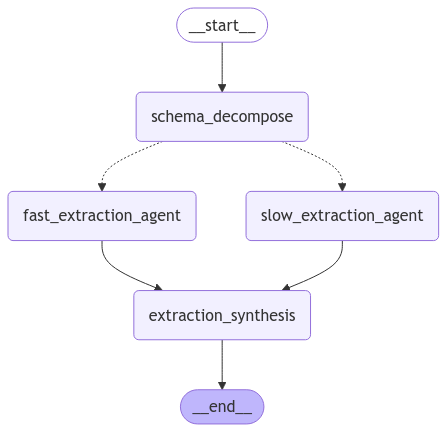

In [17]:
# Build the graph
graph_builder = StateGraph(State)
graph_builder.add_node("schema_decompose", schema_decompose)
graph_builder.add_node("fast_extraction_agent", fast_extraction_agent)
graph_builder.add_node("slow_extraction_agent", slow_extraction_agent)
graph_builder.add_node("extraction_synthesis", extraction_synthesis)
graph_builder.add_edge(START, "schema_decompose")
graph_builder.add_conditional_edges(
    "schema_decompose",
    fast_and_slow_route,
    {
        "fast_extraction_agent": "fast_extraction_agent",
        "slow_extraction_agent": "slow_extraction_agent",
    },
)
graph_builder.add_edge(
    ["fast_extraction_agent", "slow_extraction_agent"], "extraction_synthesis"
)
graph_builder.add_edge("extraction_synthesis", END)
# Compile the graph
graph = graph_builder.compile()

viz_graph(graph)

### Fast & Slow Route with DPE (Deep Extraction)
Validation loop.

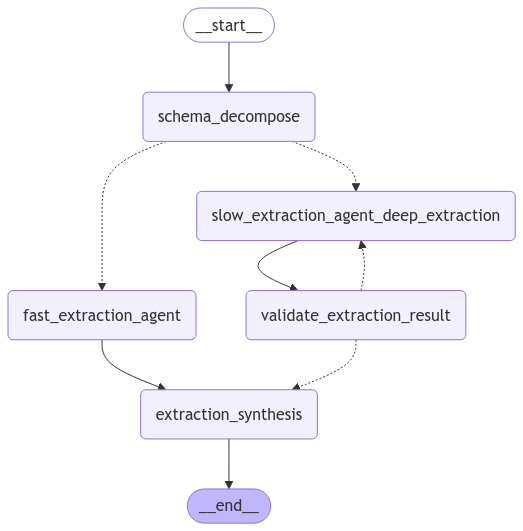

In [ ]:
# Build the graph
graph_builder_dpe = StateGraph(State)
graph_builder_dpe.add_node("schema_decompose", schema_decompose)
graph_builder_dpe.add_node("fast_extraction_agent", fast_extraction_agent)
graph_builder_dpe.add_node("slow_extraction_agent_dpe", slow_extraction_agent_dpe)
graph_builder_dpe.add_node("validate_extraction_result", validate_extraction_result)
graph_builder_dpe.add_node("extraction_synthesis", extraction_synthesis)
graph_builder_dpe.add_edge(START, "schema_decompose")
graph_builder_dpe.add_conditional_edges(
    "schema_decompose",
    fast_and_slow_route,
    {
        "fast_extraction_agent": "fast_extraction_agent",
        "slow_extraction_agent_dpe": "slow_extraction_agent_dpe",
    },
)
graph_builder_dpe.add_edge("slow_extraction_agent_dpe", "validate_extraction_result")
graph_builder_dpe.add_conditional_edges(
    "validate_extraction_result",
    validate_extraction_result_route,
    {
        "slow_extraction_agent_dpe": "slow_extraction_agent_dpe",
        "extraction_synthesis": "extraction_synthesis",
    },
)
graph_builder_dpe.add_edge("fast_extraction_agent", "extraction_synthesis")
graph_builder_dpe.add_edge("extraction_synthesis", END)
# Compile the graph
graph_dpe = graph_builder_dpe.compile()

viz_graph(graph_dpe)

In [ ]:
from langgraph.errors import GraphRecursionError

try:
    result = graph_dpe.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf",
            "json_schema": schema,
        },
        {"recursion_limit": 3},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")

In [28]:
result = graph.invoke(
    {
        "pdf_path": "data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf",
        "json_schema": schema,
    }
)
result

KeyboardInterrupt: 